<a href="https://colab.research.google.com/github/drishyatv/Online-Shopping-Purchase-Intention-Prediction/blob/main/online_shopping_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # <span style="color:blue"><b>ONLINE SHOPPING PURCHASE INTENTION PREDICTION</b></span>


Name: Drishya T V


Organization:Entri Elevate

 ## <span style="color:#1f77b4"><b>O1.Overview of the Problem statement</b></span>


With the rapid growth of e-commerce platforms, understanding and predicting customer purchasing behavior has become crucial for online businesses. Many visitors browse online shopping websites without making a purchase, leading to lost sales opportunities.

## <span style="color:#1f77b4"><b>2.Objective:</b></span>

The objective of this project is to predict whether an online shopper will make a purchase during a browsing session based on their behavior and interaction with the website. The prediction is performed using various machine learning classification algorithms by analyzing features such as page visits, time spent on different pages, visitor type, and session-related information.

By accurately predicting purchase intention, businesses can:

Improve targeted marketing strategies

Enhance user experience

Increase conversion rates and revenue

## <span style="color:#1f77b4"><b>3.Data Description</b></span>

###Source: UCI Machine Learning Repositories

###Features in the dataset:

The dataset contains 12,330 rows and 18 columns.

Each row represents a single user session on an online shopping website.
A session includes all activities performed by a user during one visit, such as page views, time spent, and interaction details.

Each column represents a specific feature that describes the user’s behavior, session characteristics, or technical information related to that visit.

Out of the 18 columns:

17 columns are independent variables (features) used as input for model training.

1 column is the dependent variable (Revenue), which indicates whether the session resulted in a purchase (True/False).


**Administrative** – Number of administrative pages visited by the user

**Administrative_Duration** – Total time spent on administrative pages

**Informational** – Number of informational pages visited

**Informational_Duration** – Total time spent on informational pages

**ProductRelated**– Number of product-related pages visited

**ProductRelated_Duration** – Total time spent on product-related pages

**BounceRates** – Percentage of visitors who leave the website after viewing one page

**ExitRates** – Percentage of users who exit from a specific page

**PageValues** – Average value of pages visited before making a purchase

**Month**– Month in which the session occurred

**SpecialDay** – Closeness of the visit to a special or festive day

**OperatingSystems** – Operating system used by the visitor

**Browser** – Browser used by the visitor

**Region** – Geographic region of the visitor

**TrafficType** – Source of website traffic

**VisitorType** – Type of visitor (New, Returning, or Other)

**Weekend** – Indicates whether the session occurred on a weekend

**Revenue** – Indicates whether the session resulted in a purchase



## <span style="color:#1f77b4"><b>4.Data Collection</b></span>


###Dataset link: https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv

## <span style="color:#1f77b4"><b>5.Implementation</b></span>

### <span style="color:#1f77b4"><b>📌Import necessary libraries</b></span>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


### <span style="color:#1f77b4"><b> ⚙️Loading dataset</b></span>

In [35]:
from google.colab import files
uploaded = files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention (2).csv


In [36]:
df = pd.read_csv("online_shoppers_intention (1).csv")

In [37]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


### <span style="color:#1f77b4"><b>📌Data understanding</b></span>

In [38]:
df.head() #displaying first 5 rows

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [39]:
df.tail() #displaying last 5 rows

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [40]:
df.info()  #data overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [41]:
df.shape

(12330, 18)

### <span style="color:#1f77b4"><b>🧹Data cleaning</b></span>

In [42]:
print(df.isnull().sum()) #check missing values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [43]:
df = df.drop_duplicates() #remove duplicates

In [44]:
df.describe() #statistical summary to understand numerical features

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


######✔ No missing values
######✔ Duplicate rows removed
######✔ Mean shows users visit product pages more
######✔ min=0, many users did not visit those pages
######✔ 50%(median), most users visit very few pages
######✔ max shows some users spend very high time/pages which indicates outliers

### <span style="color:#1f77b4"><b>  📊Exploratory Data Analysis</b></span>

#### Univariate Analysis

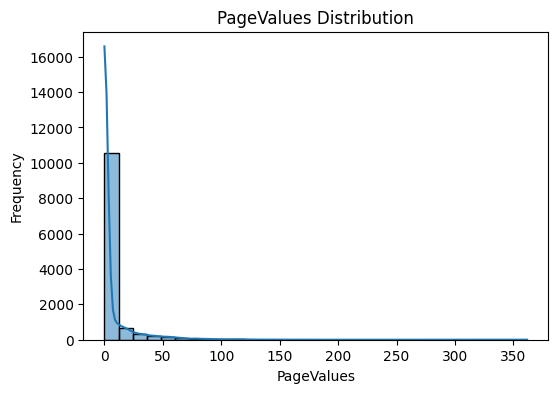

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(df['PageValues'], bins=30, kde=True)
plt.title("PageValues Distribution")
plt.xlabel("PageValues")
plt.ylabel("Frequency")
plt.show()

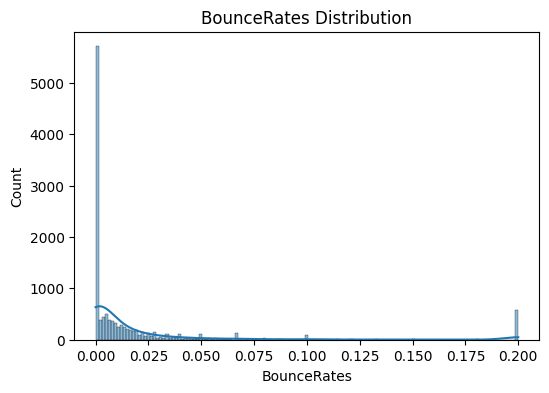

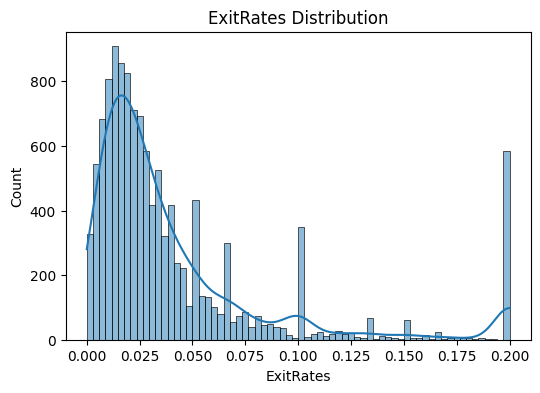

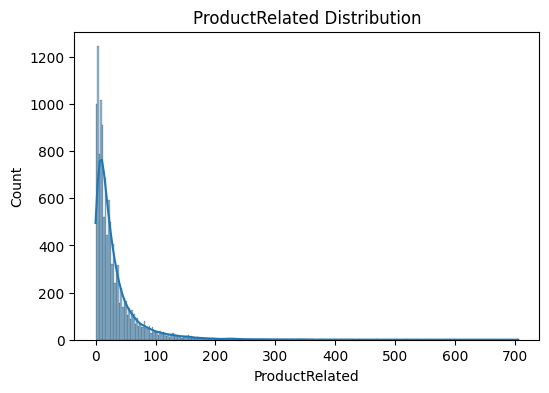

In [46]:
num_cols = ['BounceRates','ExitRates','ProductRelated']

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

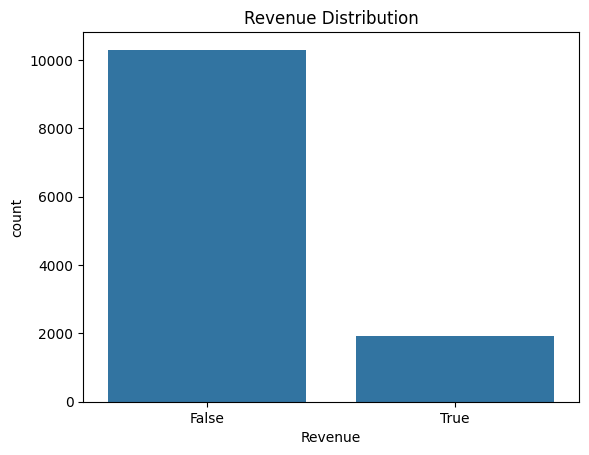

In [47]:
sns.countplot(x='Revenue', data=df) #Target Distribution
plt.title('Revenue Distribution')
plt.show()

######✔ Most numerical features are right skewed indicates many users have low values, few have very high values.Values are widely spread
######✔ BounceRates & ExitRates mostly have low values indicates many users leave quickly.
######✔ Revenue is imbalanced means more non-purchasing users than purchasing

####Bivariate Analysis

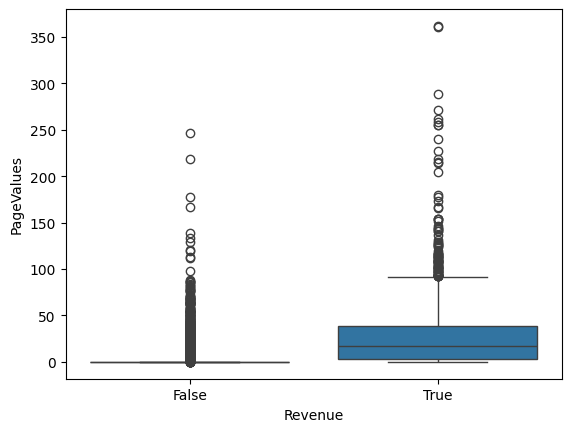

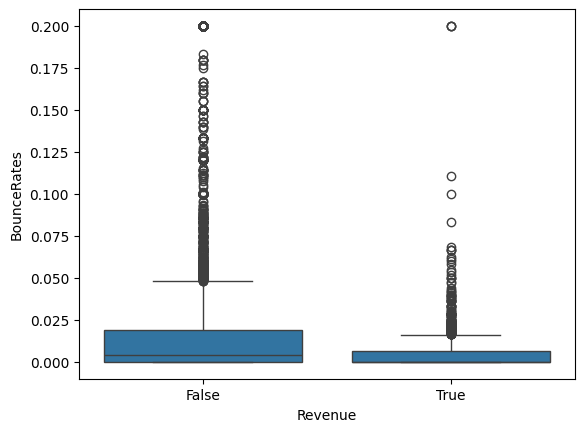

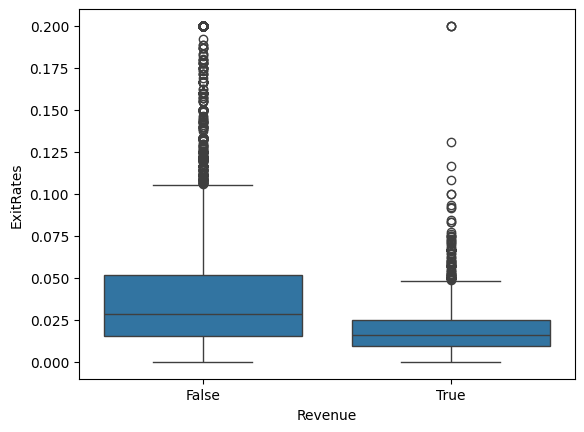

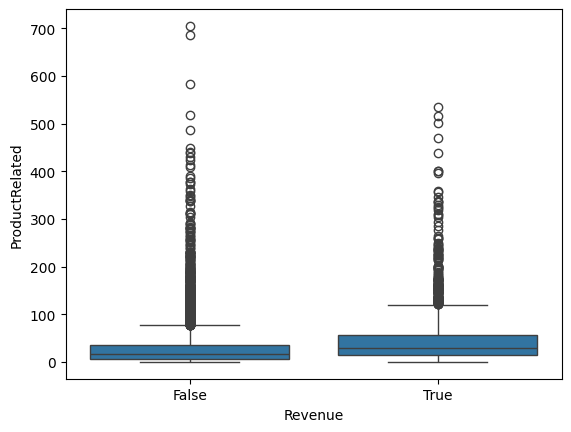

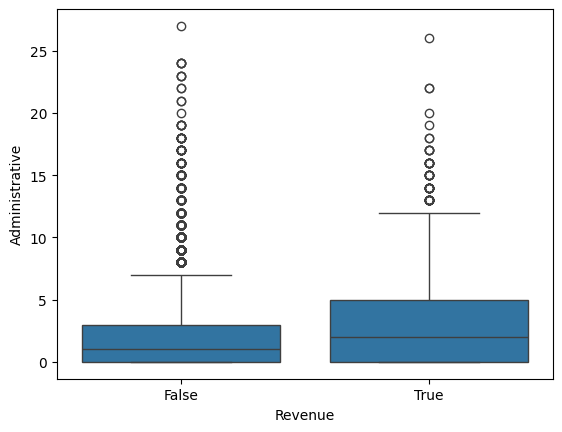

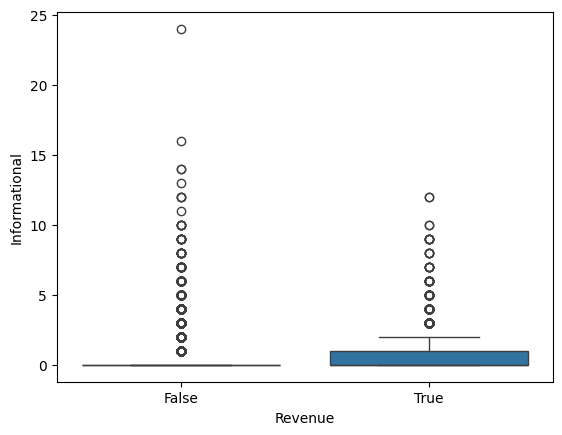

In [48]:
cols = ['PageValues','BounceRates', 'ExitRates', 'ProductRelated', 'Administrative', 'Informational']

for col in cols:
    plt.figure()
    sns.boxplot(x='Revenue', y=col, data=df)
    plt.show()

######✔ PageValues shows strong positive relationship ▶ Higher page value ▶ Higher purchase

######✔ ProductRelated also shows positive  ▶  More product page visits ▶ more purchase

######✔ BounceRates and ExitRates show negative relationship ▶ Users leaving quickly ▶ less purchase

######✔ Administrative & Informational features show ▶ weak or moderate relationship

####Correlation Analysis

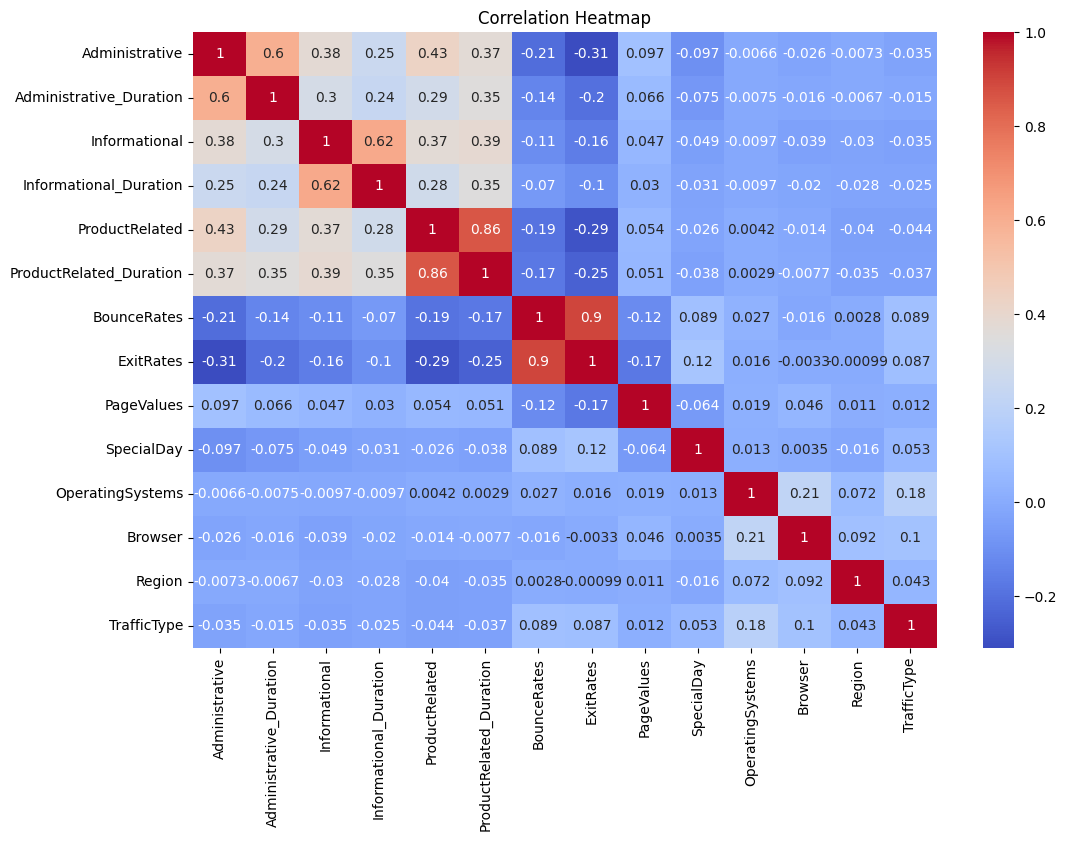

In [49]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



*   ProductRelated and ProductRelated_Duration have a strong positive correlation
(0.86), meaning users who visit more product-related pages also spend more time on them.

*   BounceRates and ExitRates show a very high positive correlation (0.90). This indicates that users who leave quickly from pages also tend to exit the website more.

*  Informational and Informational_Duration have a moderate positive correlation (0.62), showing that more informational page visits lead to more time spent there.












## <span style="color:#1f77b4"><b> 🔧Data Preprocessing</b></span>

####Convert boolean to integer

In [52]:
 df = df.copy()
 df['Weekend'] = df['Weekend'].astype(int)
 df['Revenue'] = df['Revenue'].astype(int)


####Label Encoding

In [53]:
#Create seperate encoders

le_month = LabelEncoder()
le_visitor = LabelEncoder()
df = df.copy()

#Apply encoding

df['Month'] = le_month.fit_transform(df['Month'])
df['VisitorType'] = le_visitor.fit_transform(df['VisitorType'])
#Check output

print(df[['Month' , 'VisitorType']].head())



   Month  VisitorType
0      2            2
1      2            2
2      2            2
3      2            2
4      2            2


#####converted categorical columns into numerical form using LabelEncoder.This helps the model understand and process the data.

####IQR Outlier Removal Code

In [ ]:
#select only numerical columns

num_cols = df.drop('Revenue', axis=1).select_dtypes(
    include=['int64', 'float64']
).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

### <span style="color:#1f77b4"><b>📌Train-Test Split</b></span>

In [ ]:
x = df.drop('Revenue', axis=1)
y = df['Revenue']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(y_train.value_counts())
print(y_test.value_counts())

Revenue
0    8238
1    1526
Name: count, dtype: int64
Revenue
0    2059
1     382
Name: count, dtype: int64


#####split data into training(80%) and testing(20%)

In [ ]:


df['Revenue'].value_counts()

,count
Revenue,
0,10297
1,1908


The target variable is imbalanced because non-purchasing sessions are significantly higher than purchasing sessions. Therefore, recall and F1-score are important evaluation metrics for this project.

####Feature Scaling(RobustScaler)


In [ ]:

scaler = RobustScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#####scaled features using RobustScaler to handle outliers, printed first 5 rows.

### <span style="color:#1f77b4"><b>🤖Model Building and Evaluation</b></span>

Logistic Regression Accuracy:
0.6042605489553462

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.57      0.71      2059
           1       0.25      0.77      0.38       382

    accuracy                           0.60      2441
   macro avg       0.59      0.67      0.54      2441
weighted avg       0.83      0.60      0.66      2441



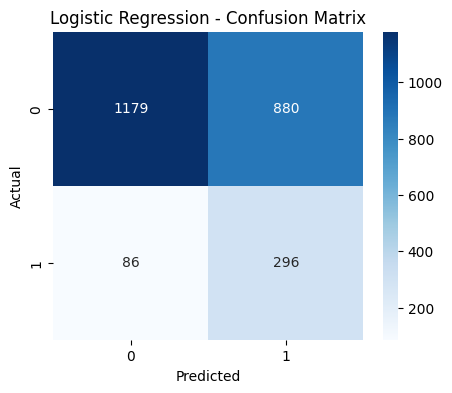

KNN Accuracy:
0.8189266693977878

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      2059
           1       0.32      0.14      0.19       382

    accuracy                           0.82      2441
   macro avg       0.59      0.54      0.54      2441
weighted avg       0.77      0.82      0.79      2441



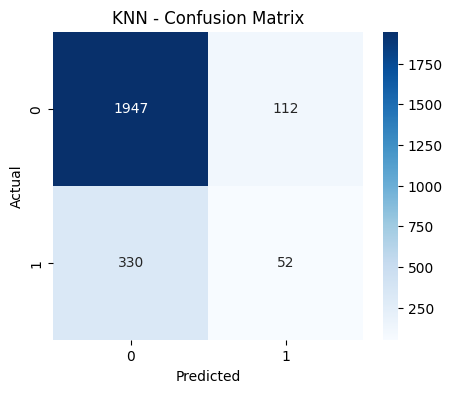

DecisionTree Accuracy:
0.782056534207292

DecisionTree Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      2059
           1       0.30      0.28      0.29       382

    accuracy                           0.78      2441
   macro avg       0.58      0.58      0.58      2441
weighted avg       0.78      0.78      0.78      2441



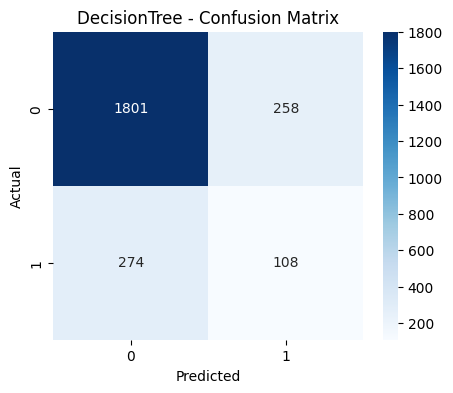

RandomForest Accuracy:
0.8385907414993855

RandomForest Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2059
           1       0.42      0.08      0.14       382

    accuracy                           0.84      2441
   macro avg       0.64      0.53      0.52      2441
weighted avg       0.78      0.84      0.79      2441



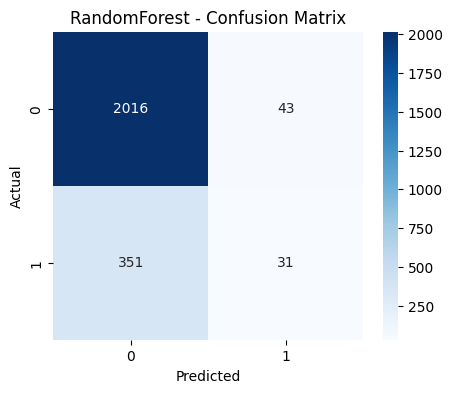

XGBoost Accuracy:
0.7632117984432609

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      2059
           1       0.32      0.45      0.37       382

    accuracy                           0.76      2441
   macro avg       0.60      0.63      0.61      2441
weighted avg       0.80      0.76      0.78      2441



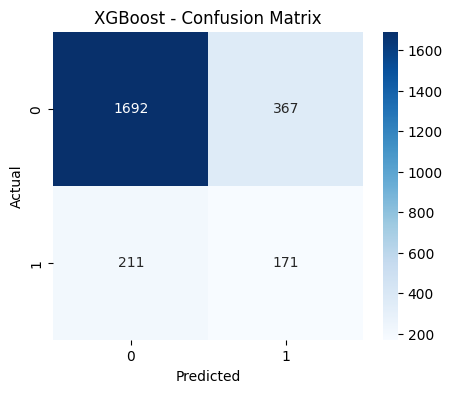

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

models = {
    "Logistic Regression":
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000
        ),

    "KNN":
        KNeighborsClassifier(),

    "DecisionTree":
        DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ),

    "RandomForest":
        RandomForestClassifier(
            class_weight='balanced',
            random_state=42
        ),



    "XGBoost":
        XGBClassifier(scale_pos_weight=scale_pos_weight,
    random_state=42)
}

for name, model in models.items():

    # Train model
    model.fit(x_train, y_train)

    # Prediction
    y_pred = model.predict(x_test)

    # Accuracy
    print(f"{name} Accuracy:")
    print(accuracy_score(y_test, y_pred))

    # Classification Report
    print(f"\n{name} Classification Report:\n")

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
     # Visualization
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

### <span style="color:#1f77b4"><b>📈Model Comparison Visualization</b></span>

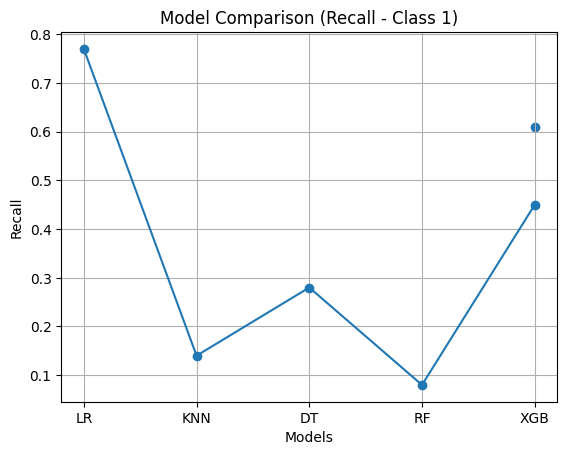

In [ ]:


model_names = ["LR","KNN","DT","RF","XGB"]
recall_scores = [0.77,0.14,0.28,0.08,0.45]

plt.figure()
plt.plot(model_names, recall_scores, marker='o')
plt.title("Model Comparison (Recall - Class 1)")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.grid()

# highlight best recall model
plt.scatter("XGB", 0.61)

plt.show()

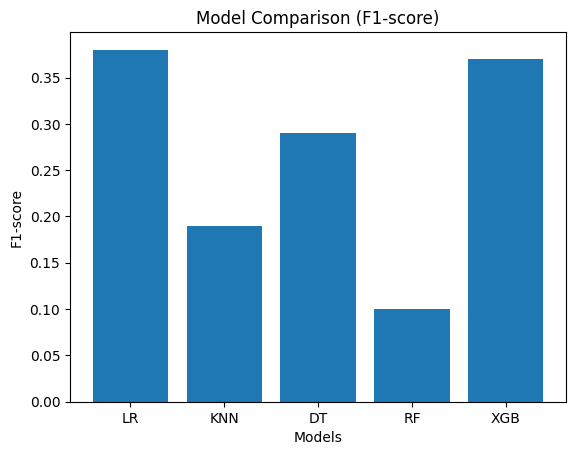

In [ ]:
model_names = ["LR","KNN","DT","RF","XGB"]
f1_scores = [0.38,0.19,0.29,0.1,0.37]



plt.bar(model_names, f1_scores)
plt.title("Model Comparison (F1-score)")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.show()

## <span style="color:#1f77b4"><b>✅Conclusion</b></span>

###In this project, multiple machine learning models were applied to predict online shopper purchase intention, including Logistic Regression, KNN, Decision Tree, Random Forest, and XGBoost. The dataset was imbalanced, with significantly more non-buyers than buyers, which affected model performance.

###Although Random Forest achieved the highest accuracy (0.84), it performed poorly in identifying actual buyers, with a very low recall for the positive class. KNN and Decision Tree also showed limited ability to detect buyers. Logistic Regression achieved the highest recall for the minority class (0.77), making it more effective in identifying potential customers, though with lower overall accuracy. XGBoost provided a better balance between precision and recall compared to other models.

###Overall, this study shows that accuracy alone is not a reliable evaluation metric for imbalanced datasets. Metrics such as recall and F1-score are more important for this problem because the main objective is to correctly identify potential buyers. Therefore, Logistic Regression and XGBoost are the most suitable models for this classification task, especially for real-world e-commerce applications where identifying customers with purchase intent is crucial for improving marketing strategies and increasing sales.